# Polish Parliament Term 10 — Exploratory Data Analysis

Goal: understand the data from several angles before committing to a network model.

Covered:
1. Data loading + shape
2. Data quality (nulls, invariants, duplicates)
3. Members
4. Proceedings
5. Votings (volume over time, controversy, outcome distribution)
6. Votes (type distribution, per-MP participation)
7. Club dynamics — switchers, and `members.club` vs `votes.club`
8. Club cohesion (within-club unity)
9. Cross-club alignment (between-club agreement)
10. Pairwise MP agreement preview
11. Network-modelling proposals with trade-offs

All club-related analysis uses `votes.club` (per-voting, time-correct). `members.club` is only a current snapshot.

## 1. Setup

In [1]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils.config import OUT_DIR

SRC_ROOT = Path('').resolve().parents[1]
PARQUET_OUT_DIR = SRC_ROOT / OUT_DIR

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

## 2. Load data

In [2]:
df_members = pd.read_parquet(PARQUET_OUT_DIR / 'members.parquet')
df_proceedings = pd.read_parquet(PARQUET_OUT_DIR / 'proceedings.parquet')
df_votings = pd.read_parquet(PARQUET_OUT_DIR / 'votings.parquet')
df_votes = pd.read_parquet(PARQUET_OUT_DIR / 'votes.parquet')

df_votings['date'] = pd.to_datetime(df_votings['date'])

for name, df in [('members', df_members), ('proceedings', df_proceedings),
                 ('votings', df_votings), ('votes', df_votes)]:
    print(f'{name:12s} shape={df.shape}')

members      shape=(498, 4)
proceedings  shape=(75, 2)
votings      shape=(3828, 10)
votes        shape=(1629218, 5)


## 3. Data quality

Verify that nothing blocks downstream analysis:
- join keys (`MP`, `sitting`, `votingNumber`) are fully populated,
- `yes + no + abstain == totalVoted` for every voting,
- no duplicate `(sitting, votingNumber)` in `votings`, no duplicate `(MP, sitting, votingNumber)` in `votes`.

In [3]:
for name, df in [('members', df_members), ('proceedings', df_proceedings),
                 ('votings', df_votings), ('votes', df_votes)]:
    nulls = df.isna().sum()
    nulls = nulls[nulls > 0]
    print(f'{name:12s}:', dict(nulls) if len(nulls) else 'no nulls')

members     : no nulls
proceedings : no nulls
votings     : no nulls
votes       : no nulls


In [4]:
sum_check = df_votings['yes'] + df_votings['no'] + df_votings['abstain']
mismatch = (sum_check != df_votings['totalVoted']).sum()
print(f'yes+no+abstain != totalVoted: {mismatch} / {len(df_votings)} votings')

dup_votings = df_votings.duplicated(subset=['sitting', 'votingNumber']).sum()
dup_votes = df_votes.duplicated(subset=['MP', 'sitting', 'votingNumber']).sum()
print(f'duplicate (sitting, votingNumber) in votings: {dup_votings}')
print(f'duplicate (MP, sitting, votingNumber) in votes: {dup_votes}')

yes+no+abstain != totalVoted: 34 / 3828 votings
duplicate (sitting, votingNumber) in votings: 0
duplicate (MP, sitting, votingNumber) in votes: 0


## 4. Members

Size of the chamber and club composition (note: snapshot only — see §7 for time-correct club info).

Total members: 498
club
PiS                202
KO                 174
PSL-TD              33
Lewica              23
Konfederacja        18
Centrum             15
Polska2050          15
niez.                6
Demokracja           4
Razem                4
Konfederacja_KP      3
Polska2050-TD        1
Name: count, dtype: int64


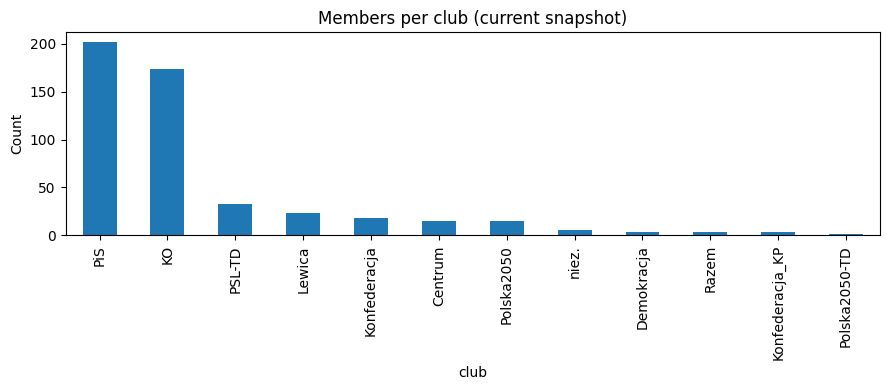

In [5]:
print(f'Total members: {len(df_members)}')
club_counts = df_members['club'].value_counts()
print(club_counts)

fig, ax = plt.subplots(figsize=(9, 4))
club_counts.plot(kind='bar', ax=ax)
ax.set_title('Members per club (current snapshot)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 5. Proceedings

In [6]:
print(f'Proceedings (sittings):   {len(df_proceedings)}')
print(f'Sitting range:            {df_proceedings.sitting.min()}{df_proceedings.sitting.max()}')
print(f'First ELECTRONIC voting:  {df_votings.date.min()}')
print(f'Last  ELECTRONIC voting:  {df_votings.date.max()}')

Proceedings (sittings):   75
Sitting range:            056
First ELECTRONIC voting:  2023-11-13 18:02:12
Last  ELECTRONIC voting:  2026-04-17 11:02:25


## 6. Votings

### 6.1 Voting kind

Should be all `ELECTRONIC` — the scraper drops other kinds because they don't carry per-MP data.

In [7]:
print(df_votings['kind'].value_counts())

kind
ELECTRONIC    3828
Name: count, dtype: int64


### 6.2 Volume over time

Monthly voting counts. Useful later for deciding temporal slices (e.g. before/after government change in Dec 2023).

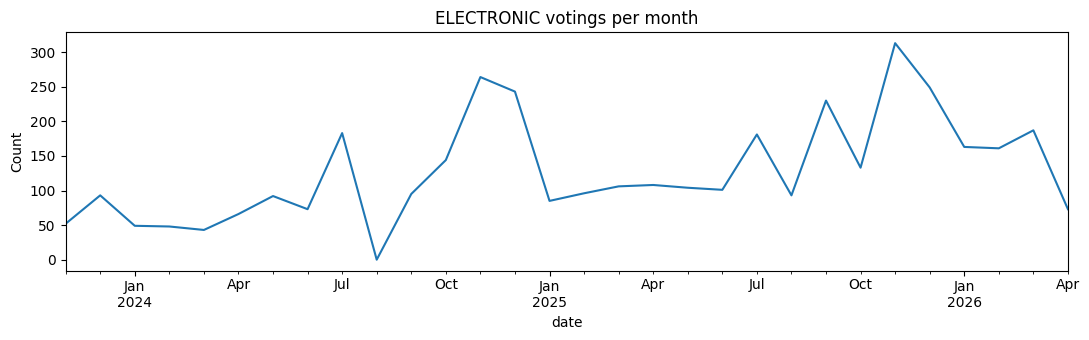

In [8]:
monthly = df_votings.set_index('date').resample('ME').size()
fig, ax = plt.subplots(figsize=(11, 3.5))
monthly.plot(ax=ax)
ax.set_title('ELECTRONIC votings per month')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 6.3 Outcome distribution

For each voting, `winning_share = max(yes, no, abstain) / totalVoted`.
- 1.0 → unanimous on one option.
- ~0.5 → close vote.
- near 0.33 → three-way split.

Near-unanimous votings (say ≥ 0.95) carry almost no signal for MP similarity and should be down-weighted or dropped before modelling.

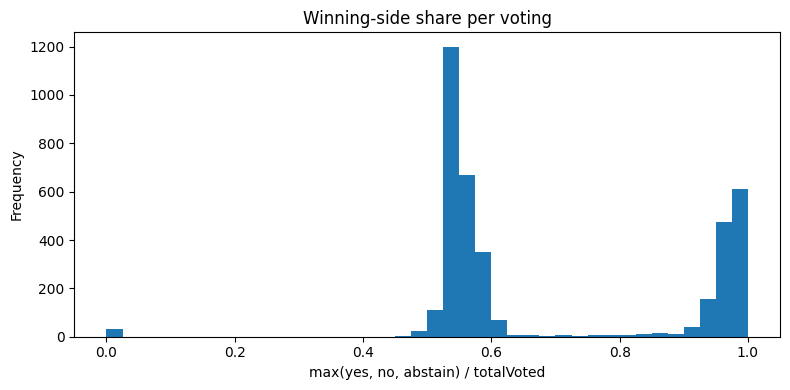

share with winning_share >= 0.95: 28.5%
share with winning_share >= 0.90: 33.5%
share with winning_share >= 0.75: 35.1%
share with winning_share >= 0.60: 37.7%


In [9]:
vals = df_votings[['yes','no','abstain']].to_numpy()
df_votings['winning_share'] = vals.max(axis=1) / df_votings['totalVoted']

fig, ax = plt.subplots(figsize=(8, 4))
df_votings['winning_share'].plot.hist(bins=40, ax=ax)
ax.set_title('Winning-side share per voting')
ax.set_xlabel('max(yes, no, abstain) / totalVoted')
plt.tight_layout()
plt.show()

for t in [0.95, 0.90, 0.75, 0.60]:
    share = (df_votings['winning_share'] >= t).mean()
    print(f'share with winning_share >= {t:.2f}: {share:.1%}')

### 6.4 Most and least controversial votings

In [10]:
cols = ['sitting','votingNumber','yes','no','abstain','totalVoted','winning_share','topic']
print('Most contested:')
print(df_votings.nsmallest(5, 'winning_share')[cols].to_string(index=False))
print()
print('Most unanimous:')
print(df_votings.nlargest(5, 'winning_share')[cols].to_string(index=False))

Most contested:
 sitting  votingNumber  yes  no  abstain  totalVoted  winning_share                         topic
      18            46    0   0        0         396            0.0 wniosek o stwierdzenie kworum
      20             7    0   0        0         427            0.0             Głosowanie kworum
      21             5    0   0        0         432            0.0             Głosowanie kworum
      21            21    0   0        0         412            0.0             Głosowanie kworum
      22            15    0   0        0         404            0.0             Głosowanie kworum

Most unanimous:
 sitting  votingNumber  yes  no  abstain  totalVoted  winning_share                                                                                                topic
       1             2  458   0        0         458            1.0 Pkt. 2 Poselskie projekty uchwał w sprawie ustalenia liczby Wicemarszałków Sejmu RP (druki nr 1 i 2)
       1             9  457   0        0 

## 7. Votes

### 7.1 Vote type distribution

vote
YES        0.529
NO         0.419
ABSTAIN    0.052
Name: proportion, dtype: float64


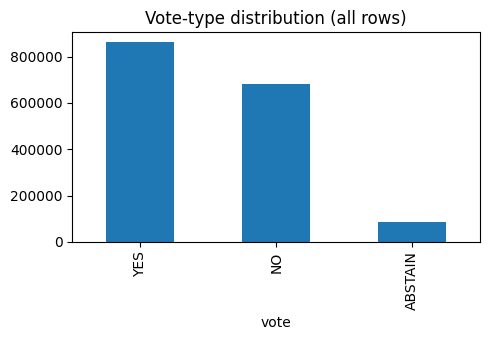

In [11]:
print(df_votes['vote'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 3.5))
df_votes['vote'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Vote-type distribution (all rows)')
plt.tight_layout()
plt.show()

### 7.2 Per-MP participation

`participation = (votings this MP was present for) / (total votings)`. Absence = no row in `votes` for that voting.
Low-participation MPs distort similarity metrics — relevant for later co-presence thresholding.

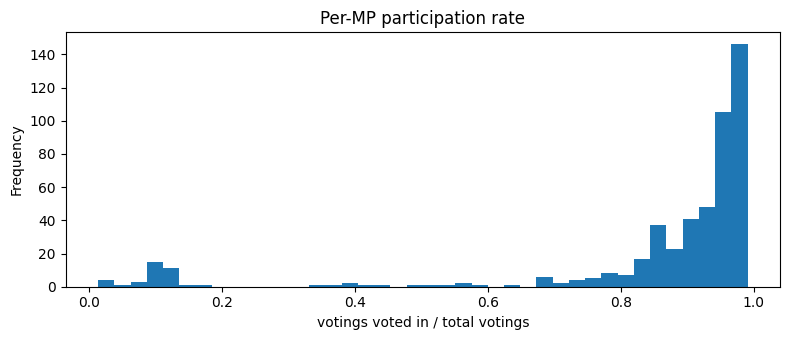

Median:     0.944
10th pct:   0.676
MPs < 10% participation: 15
MPs < 50% participation: 42


In [12]:
total_votings = len(df_votings)
per_mp_present = df_votes.groupby('MP').size()
participation = per_mp_present / total_votings

fig, ax = plt.subplots(figsize=(8, 3.5))
participation.plot.hist(bins=40, ax=ax)
ax.set_title('Per-MP participation rate')
ax.set_xlabel('votings voted in / total votings')
plt.tight_layout()
plt.show()

print(f'Median:     {participation.median():.3f}')
print(f'10th pct:   {participation.quantile(0.10):.3f}')
print(f'MPs < 10% participation: {(participation < 0.1).sum()}')
print(f'MPs < 50% participation: {(participation < 0.5).sum()}')

### 7.3 MPs in votes vs members

In [13]:
votes_mps = set(df_votes['MP'].unique())
members_mps = set(df_members['MP'].unique())
print(f'In votes, not in members: {len(votes_mps - members_mps)}')
print(f'In members, never voted:  {len(members_mps - votes_mps)}')

In votes, not in members: 0
In members, never voted:  0


## 8. Club dynamics (switchers)

`votes.club` is the club at the moment of each vote — so an MP with more than one distinct value across votes is a switcher.

In [14]:
clubs_per_mp = df_votes.groupby('MP')['club'].nunique()
print('MPs by number of distinct clubs seen in votes:')
print(clubs_per_mp.value_counts().sort_index())
print(f'\nSwitchers (>1 club): {(clubs_per_mp > 1).sum()}')

MPs by number of distinct clubs seen in votes:
club
1    395
2     74
3     23
4      5
5      1
Name: count, dtype: int64

Switchers (>1 club): 103


In [15]:
switchers = clubs_per_mp[clubs_per_mp > 1].index
votes_with_date = df_votes.merge(
    df_votings[['sitting','votingNumber','date']],
    on=['sitting','votingNumber'],
)
mp_club_sequence = (
    votes_with_date[votes_with_date.MP.isin(switchers)]
    .sort_values('date')
    .groupby('MP')['club']
    .agg(first='first', last='last', n_clubs='nunique')
    .merge(df_members[['MP','firstName','lastName']], on='MP')
    .sort_values('n_clubs', ascending=False)
)
print(mp_club_sequence.head(20).to_string(index=False))

 MP        first            last  n_clubs   firstName      lastName
  6          PiS      Demokracja        5         Jan    Ardanowski
139          PiS           niez.        4       Marek      Jakubiak
239  Nowa_Lewica           niez.        4     Paulina      Matysiak
200          PiS      Demokracja        4       Paweł         Kukiz
321          PiS      Demokracja        4    Jarosław      Sachajko
 23   Polska2050         Centrum        4     Izabela        Bodnar
171   Polska2050         Centrum        3       Rafał    Komarewicz
128   Polska2050         Centrum        3     Paulina Hennig-Kloska
211   Polska2050         Centrum        3  Aleksandra           Leo
359   Polska2050         Centrum        3    Mirosław        Suchoń
252   Polska2050           niez.        3      Joanna         Mucha
 39   Polska2050         Centrum        3    Elżbieta    Burkiewicz
172  Nowa_Lewica           Razem        3      Maciej     Konieczny
271   Polska2050         Centrum        3     Ba

### 8.1 `members.club` vs last observed club in votes

Confirms the snapshot is not authoritative — any per-vote analysis must use `votes.club`.

In [16]:
last_club = (
    votes_with_date.sort_values('date')
    .groupby('MP')['club'].last()
    .rename('last_vote_club')
)
m = df_members[['MP','club']].merge(last_club, left_on='MP', right_index=True)
disc = (m['club'] != m['last_vote_club']).sum()
print(f'members.club differs from last_vote_club: {disc} / {len(m)}')

members.club differs from last_vote_club: 0 / 498


## 9. Club cohesion

Per `(club, voting)`: **cohesion = plurality share of the club's votes** (how aligned the club was on that vote).

Mean cohesion per club tells us which clubs act like disciplined blocks and which are loose.

In [17]:
club_voting = (
    df_votes.groupby(['club','sitting','votingNumber','vote'])
    .size()
    .unstack('vote', fill_value=0)
)
for col in ('YES','NO','ABSTAIN'):
    if col not in club_voting.columns:
        club_voting[col] = 0
club_voting = club_voting[['YES','NO','ABSTAIN']]
club_voting['total'] = club_voting.sum(axis=1)
club_voting['max']   = club_voting[['YES','NO','ABSTAIN']].max(axis=1)
club_voting['cohesion'] = club_voting['max'] / club_voting['total']

cohesion_by_club = (
    club_voting.reset_index()
    .groupby('club')['cohesion']
    .agg(mean='mean', median='median', std='std', n_votings='count')
    .sort_values('mean', ascending=False)
)
print(cohesion_by_club.to_string())

                     mean  median       std  n_votings
club                                                  
Nowa_Lewica      1.000000     1.0  0.000000          7
PSL              1.000000     1.0  0.000000          7
KO               0.997441     1.0  0.018249       3794
Centrum          0.995706     1.0  0.024436        336
Polska2050-TD    0.994242     1.0  0.036455       2582
Polska2050       0.993205     1.0  0.028157       1212
Razem            0.992167     1.0  0.052467       2830
PSL-TD           0.992040     1.0  0.038288       3787
Lewica           0.989508     1.0  0.049494       3787
Konfederacja_KP  0.987235     1.0  0.067410       1854
PiS              0.987124     1.0  0.052435       3790
Kukiz15          0.978513     1.0  0.085626        892
Konfederacja     0.956394     1.0  0.107582       3790
Demokracja       0.946602     1.0  0.138537        515
Republikanie     0.935146     1.0  0.128633       2372
niez.            0.870138     1.0  0.177685       3409


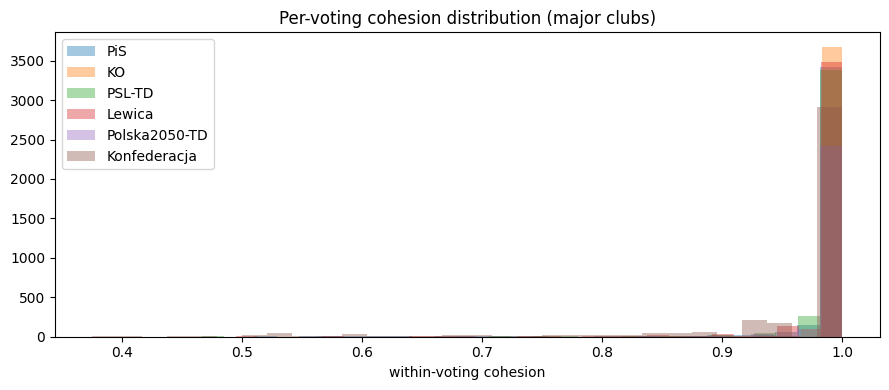

In [18]:
major_clubs = df_votes.club.value_counts().head(6).index.tolist()
fig, ax = plt.subplots(figsize=(9, 4))
for c in major_clubs:
    sub = club_voting.reset_index()
    sub = sub[sub.club == c]
    ax.hist(sub['cohesion'], bins=30, alpha=0.4, label=c)
ax.set_xlabel('within-voting cohesion')
ax.set_title('Per-voting cohesion distribution (major clubs)')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Cross-club alignment

Reduce each `(club, voting)` to the **club's majority vote** (YES / NO / ABSTAIN). Between every pair of clubs, compute the share of votings where majorities match. Gives a first look at coalition structure before MP-level modelling.

In [19]:
majority = club_voting[['YES','NO','ABSTAIN']].idxmax(axis=1)
majority = majority.unstack('club')[major_clubs]

n = len(major_clubs)
mat = np.full((n, n), np.nan)
for i, a in enumerate(major_clubs):
    for j, b in enumerate(major_clubs):
        if i == j:
            mat[i, j] = 1.0
            continue
        both = majority[[a, b]].dropna()
        if len(both):
            mat[i, j] = (both.iloc[:, 0] == both.iloc[:, 1]).mean()
agreement = pd.DataFrame(mat, index=major_clubs, columns=major_clubs)
print(agreement.round(3))

                 PiS     KO  PSL-TD  Lewica  Polska2050-TD  Konfederacja
PiS            1.000  0.352   0.357   0.348          0.370         0.522
KO             0.352  1.000   0.988   0.969          0.985         0.326
PSL-TD         0.357  0.988   1.000   0.960          0.979         0.331
Lewica         0.348  0.969   0.960   1.000          0.953         0.313
Polska2050-TD  0.370  0.985   0.979   0.953          1.000         0.316
Konfederacja   0.522  0.326   0.331   0.313          0.316         1.000


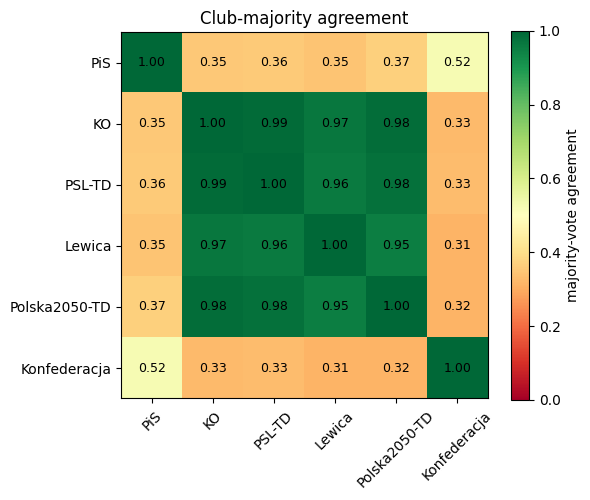

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(agreement.astype(float).values, vmin=0, vmax=1, cmap='RdYlGn')
ax.set_xticks(range(len(major_clubs))); ax.set_xticklabels(major_clubs, rotation=45)
ax.set_yticks(range(len(major_clubs))); ax.set_yticklabels(major_clubs)
for i in range(len(major_clubs)):
    for j in range(len(major_clubs)):
        ax.text(j, i, f'{agreement.iloc[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='majority-vote agreement')
ax.set_title('Club-majority agreement')
plt.tight_layout()
plt.show()

## 11. Pairwise MP agreement (preview)

Small sample: 5 MPs per major club. For each pair, restrict to votings where both were present, then compute the share where they voted identically (YES=YES, NO=NO, ABS=ABS). This is the simplest MP-level similarity and previews what the full modelling will produce.

In [21]:
rng = np.random.default_rng(0)
sample_mps = []
for c in major_clubs:
    mps_in_club = df_votes[df_votes.club == c]['MP'].unique()
    k = min(5, len(mps_in_club))
    sample_mps.extend(rng.choice(mps_in_club, size=k, replace=False))
sample_mps = sorted(set(int(x) for x in sample_mps))

encoding = {'YES': 1, 'NO': -1, 'ABSTAIN': 0}
sub = df_votes[df_votes.MP.isin(sample_mps)].copy()
sub['val'] = sub['vote'].map(encoding)
mat = sub.pivot_table(index='MP',
                      columns=['sitting','votingNumber'],
                      values='val',
                      aggfunc='first')
print(f'Sample matrix: {mat.shape}  (MPs × votings)')

Sample matrix: (30, 3794)  (MPs × votings)


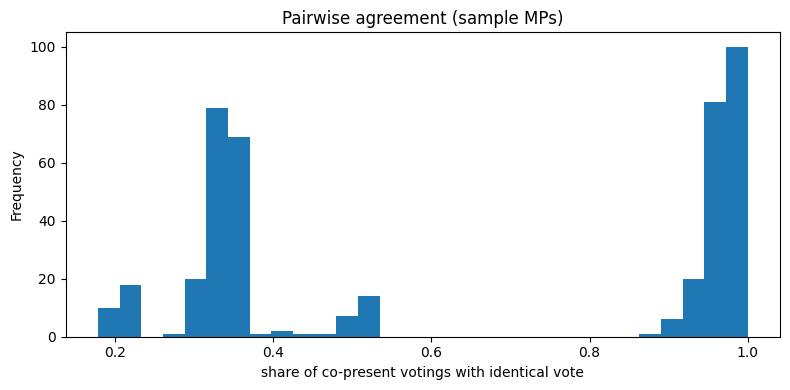

count    431.000
mean       0.643
std        0.320
min        0.178
25%        0.336
50%        0.518
75%        0.971
max        1.000
Name: agreement, dtype: float64


In [22]:
pairs = []
for a, b in combinations(mat.index, 2):
    va, vb = mat.loc[a], mat.loc[b]
    mask = va.notna() & vb.notna()
    n = int(mask.sum())
    if n < 20:
        continue
    agree = float((va[mask] == vb[mask]).mean())
    pairs.append({'a': a, 'b': b, 'co_present': n, 'agreement': agree})
pair_df = pd.DataFrame(pairs)

fig, ax = plt.subplots(figsize=(8, 4))
pair_df['agreement'].plot.hist(bins=30, ax=ax)
ax.set_title('Pairwise agreement (sample MPs)')
ax.set_xlabel('share of co-present votings with identical vote')
plt.tight_layout()
plt.show()

print(pair_df['agreement'].describe().round(3))

In [23]:
mp_modal_club = df_votes.groupby('MP')['club'].agg(lambda s: s.mode().iloc[0])
pair_df['same_club'] = pair_df.apply(
    lambda r: mp_modal_club.loc[r.a] == mp_modal_club.loc[r.b], axis=1
)
print(pair_df.groupby('same_club')['agreement'].describe().round(3))

           count   mean    std    min    25%    50%    75%    max
same_club                                                        
False      375.0  0.593  0.314  0.178  0.333  0.359  0.962  0.997
True        56.0  0.977  0.023  0.904  0.969  0.984  0.992  1.000


## 12. Network-modelling proposals

From the EDA above, key facts to design around:
- ~500 MPs, ~3.8k ELECTRONIC votings, ~1.6M vote rows → any N×N MP matrix is cheap; storing per-voting vectors is fine.
- Vote distribution is YES-heavy (most bills pass with large majorities). A large chunk of votings are near-unanimous → noise unless down-weighted.
- Several MPs are switchers. The per-vote `club` must be used, never the snapshot.
- Participation is non-uniform; a co-presence floor is needed so that low-attendance MPs don't produce noisy similarities.

---

### Option A — "YES co-vote" weighted graph (original idea)
Edge weight = number of votings where both voted YES.
- **+** Very simple, directly interpretable.
- **−** Ignores NO-NO agreement → opposition clubs look disconnected even when aligned.
- **−** Biased toward active MPs and toward YES-heavy agenda items; near-unanimous votes dominate.
- **−** Conflates absence with disagreement.
- Verdict: not recommended as the main model.

### Option B — Full agreement weighted graph
Edge weight = count of votings where both voted identically (YES-YES ∪ NO-NO ∪ ABS-ABS), divided by co-presence count.
- **+** Captures both coalition and shared-opposition alignment.
- **+** Normalises by co-presence → less biased by attendance.
- **−** Ignores the sign/structure of votes (an abstention agreement counts the same as a substantive YES agreement).
- **−** Still dominated by unanimous votings unless those are filtered/weighted.

### Option C — Cosine similarity on ±1/0 vectors *(recommended baseline)*
Encode YES=+1, NO=−1, ABSTAIN=0, absent=NaN. For each pair compute cosine only over co-presence; optionally weight each voting by its controversy (e.g. `1 − winning_share`).
- **+** Distinguishes opposite votes from mere abstention disagreement.
- **+** Directly comparable to W-NOMINATE / political-science literature.
- **+** Controversy weighting drops noise from near-unanimous bills.
- **−** Slightly more work to explain than Option B, but still standard.

### Option D — Signed network
Edge weight ∈ [−1, 1] = (agreements − disagreements) / co-presence.
- **+** Enables structural-balance analysis: polarisation, balanced triangles, signed communities.
- **+** Very expressive — one edge carries both sign and strength.
- **−** Fewer off-the-shelf tools than unsigned; community detection needs signed algorithms (e.g. SPONGE, SignedLouvain).
- Good as a **second** angle on top of Option C.

### Option E — Bipartite MP ↔ voting, projected
Two node types: MPs and votings, edge when MP cast a non-abstain vote.
- **+** Natural fit for the raw data; lets you analyse which votings are structurally pivotal (via voting-node centralities).
- **+** Projections onto either side are cheap.
- **−** Loses the YES vs NO distinction unless you split into two bipartite graphs (one for YES, one for NO).
- Mostly interesting if you want to study the **votings themselves** as first-class objects.

### Option F — Multilayer (future-looking)
Layers:
1. Voting-agreement (from Option C).
2. Bill co-sponsorship (via `/term10/prints` — who co-signs which bills).
3. Committee co-membership (via `/term10/committees`).
- **+** Structurally richest and the most "Complex Networks course"-shaped angle.
- **+** Layers disagree in informative ways — co-sponsorship is voluntary, voting is often whipped.
- **−** Requires extending the scraper. Only worth it after the single-layer baseline is solid.

### Option G — Temporal slices
Separate networks per quarter or per legislative phase (pre-Dec 2023, coalition formation, government phase).
- **+** Term 10 had a government change in Dec 2023 — natural before/after contrast.
- **+** Enables dynamic analysis: who moves closer/farther, emerging communities.
- **−** Small slices increase noise; need to keep per-pair co-presence thresholds.
- Apply on top of whichever static model you pick.

---

### Recommendation

1. **Baseline:** Option C with
   - controversy weighting (drop or down-weight votings with `winning_share ≥ 0.95`),
   - co-presence floor ≥ 50 shared votings,
   - sparsification via disparity filter (α = 0.05) to produce the analysable graph.
2. **Complementary angle:** Option D (signed) on the same similarity matrix — same data, different questions (polarisation, balance).
3. **Over time:** pick 2–3 temporal slices (Option G) once the static pipeline works.
4. **Stretch goal:** Option F if time permits — adds the "multilayer" dimension expected in Complex Networks work.